Original shape: (150, 4)
Number of classes: 3

LDA reduced shape: (150, 2)


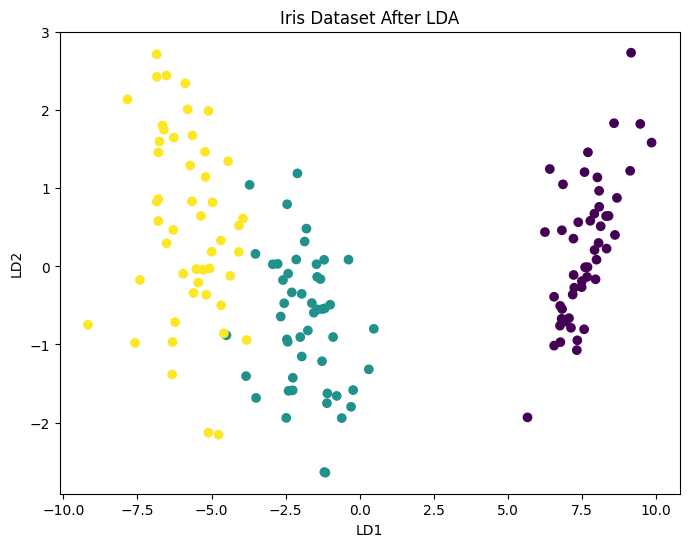


Within-class scatter matrix S_W:
[[57.19414039 38.01741201 16.95864185  9.00354437]
 [38.01741201 89.88257294 10.62508571 14.57007861]
 [16.95864185 10.62508571  8.79424214  4.69233162]
 [ 9.00354437 14.57007861  4.69233162 10.66756048]]

Between-class scatter matrix S_B:
[[ 92.80585961 -55.65287963 113.80442453 113.68762457]
 [-55.65287963  60.11742706 -74.89110136 -69.48896849]
 [113.80442453 -74.89110136 141.20575786 139.73748309]
 [113.68762457 -69.48896849 139.73748309 139.33243952]]

1D LDA shape: (150, 1)


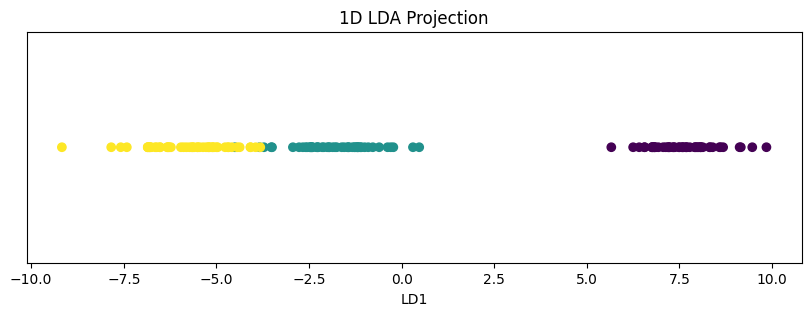


Accuracy: 1.0


NotImplementedError: transform not implemented for 'lsqr' solver (use 'svd' or 'eigen').

In [1]:
# ============================================================
# LDA — LINEAR DISCRIMINANT ANALYSIS
# DIMENSIONALITY REDUCTION 🟡
# ============================================================
#
# DEPTH:
#   🟡 Medium
#
# IMPORTANT:
#
# We already studied LDA for CLASSIFICATION.
#
# Here we focus on:
#
#     LDA as a DIMENSIONALITY REDUCTION technique.
#
#
# Main idea:
#
#     PCA:
#         Find directions of maximum variance.
#
#     LDA:
#         Find directions that best separate classes.
#
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

from sklearn.preprocessing import StandardScaler

from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis
)

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score


# ============================================================
# 2. WHY LDA FOR DIMENSIONALITY REDUCTION?
# ============================================================
#
# Suppose we have:
#
#     100 features
#
# and:
#
#     3 classes
#
#
# We may want to reduce:
#
#     100 dimensions
#          ↓
#      2 dimensions
#
#
# But we don't just want arbitrary dimensions.
#
# We want the new dimensions to preserve CLASS SEPARATION.
#
#
# This is where LDA differs from PCA.
#
# ============================================================


# ============================================================
# 3. CORE INTUITION ⭐⭐⭐
# ============================================================
#
# Imagine two classes:
#
#
# Class A:
#
#     ● ● ●
#      ● ●
#       ●
#
#
# Class B:
#
#                    ○
#                  ○ ○ ○
#                   ○ ○
#
#
# There may be many possible projection directions.
#
#
# LDA asks:
#
#     "Which direction makes the class means far apart
#      while keeping points within each class close together?"
#
#
# That is the central idea.
#
# ============================================================


# ============================================================
# 4. PCA VS LDA ⭐⭐⭐
# ============================================================
#
#
# PCA:
#
#     Does NOT use labels.
#
#     Objective:
#
#         Maximize total variance.
#
#
# LDA:
#
#     Uses labels.
#
#     Objective:
#
#         Maximize between-class separation
#         relative to within-class variation.
#
#
# Mental model:
#
#
# PCA:
#
#     "Where is the data spread out?"
#
#
# LDA:
#
#     "Where are the classes best separated?"
#
# ============================================================


# ============================================================
# 5. THE TWO TYPES OF VARIATION ⭐⭐⭐
# ============================================================
#
# LDA considers:
#
#
# 1. WITHIN-CLASS VARIATION
#
# How spread out are points INSIDE each class?
#
#
# We want:
#
#     LOW within-class variation.
#
#
# ------------------------------------------------------------
#
# 2. BETWEEN-CLASS VARIATION
#
# How far apart are the class means?
#
#
# We want:
#
#     HIGH between-class variation.
#
#
# Therefore:
#
#
#        BETWEEN-CLASS SEPARATION
# LDA = -----------------------------
#        WITHIN-CLASS VARIATION
#
#
# We want this ratio to be large.
#
# ============================================================


# ============================================================
# 6. WITHIN-CLASS SCATTER MATRIX ⭐⭐⭐
# ============================================================
#
# For each class k:
#
#
#     S_k =
#
#     Σ (x_i - μ_k)(x_i - μ_k)^T
#
#
# where:
#
#     μ_k = mean of class k
#
#
# Total within-class scatter:
#
#
#     S_W = Σ_k S_k
#
#
# Intuition:
#
#     S_W tells us how much points vary inside their classes.
#
#
# LDA wants this to be small after projection.
#
# ============================================================


# ============================================================
# 7. BETWEEN-CLASS SCATTER MATRIX ⭐⭐⭐
# ============================================================
#
# Let:
#
#     μ_k = mean of class k
#
#     μ   = overall mean
#
#
# Then:
#
#
#     S_B =
#
#     Σ_k n_k
#         (μ_k - μ)(μ_k - μ)^T
#
#
# where:
#
#     n_k = number of samples in class k
#
#
# Intuition:
#
#     S_B tells us how far class means are from the overall
#     mean.
#
#
# LDA wants this to be large.
#
# ============================================================


# ============================================================
# 8. FISHER'S CRITERION ⭐⭐⭐
# ============================================================
#
# For a projection direction w:
#
#
#             wᵀ S_B w
#
#     J(w) = -----------
#             wᵀ S_W w
#
#
# We want to maximize:
#
#     J(w)
#
#
# Meaning:
#
#     large between-class separation
#
# divided by
#
#     small within-class spread.
#
#
# This is the heart of LDA dimensionality reduction.
#
# ============================================================


# ============================================================
# 9. THE KEY EIGENVALUE PROBLEM ⭐⭐⭐
# ============================================================
#
# Maximizing Fisher's criterion leads to:
#
#
#     S_B w = λ S_W w
#
#
# or conceptually:
#
#
#     S_W^-1 S_B w = λw
#
#
#
# Eigenvectors:
#
#     discriminant directions
#
#
# Eigenvalues:
#
#     importance of those directions.
#
#
# Sort eigenvectors by eigenvalues.
#
# Keep the most useful directions.
#
# ============================================================


# ============================================================
# 10. IMPORTANT LIMITATION ⭐⭐⭐
# ============================================================
#
# If there are K classes:
#
#
# Maximum number of LDA components:
#
#
#     min(number_of_features,
#         K - 1)
#
#
# Example:
#
#     3 classes
#
#     maximum components = 2
#
#
# 5 classes:
#
#     maximum components = 4
#
#
# 2 classes:
#
#     maximum components = 1
#
#
# This is a very common interview question.
#
# ============================================================


# ============================================================
# 11. LOAD IRIS
# ============================================================

iris = load_iris()

X = iris.data

y = iris.target

print(
    "Original shape:",
    X.shape
)

print(
    "Number of classes:",
    len(np.unique(y))
)


# ============================================================
# 12. STANDARDIZATION
# ============================================================
#
# Scaling is commonly useful for distance/scatter based
# methods when features have different scales.
#
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ============================================================
# 13. BASIC LDA DIMENSIONALITY REDUCTION
# ============================================================
#
# Iris has:
#
#     3 classes
#
# Therefore maximum:
#
#     K - 1 = 2
#
# discriminant components.
#
# ============================================================

lda = LinearDiscriminantAnalysis(
    n_components=2
)

X_lda = lda.fit_transform(
    X_scaled,
    y
)

print(
    "\nLDA reduced shape:",
    X_lda.shape
)


# ============================================================
# 14. VISUALIZE LDA PROJECTION
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X_lda[:, 0],
    X_lda[:, 1],
    c=y
)

plt.xlabel(
    "LD1"
)

plt.ylabel(
    "LD2"
)

plt.title(
    "Iris Dataset After LDA"
)

plt.show()


# ============================================================
# 15. WHAT HAPPENED?
# ============================================================
#
# Original:
#
#     4 features
#
#
# LDA:
#
#     4 dimensions
#          ↓
#     2 discriminant dimensions
#
#
# But unlike PCA:
#
#     LDA used y.
#
#
# It specifically searched for projections that separate:
#
#     Class 0
#     Class 1
#     Class 2
#
# ============================================================


# ============================================================
# 16. IMPLEMENT THE CORE SCATTER MATRICES
# ============================================================
#
# This is useful for understanding the internals.
#
# We are NOT building a complete production LDA implementation.
#
# We are explicitly calculating:
#
#     S_W
#     S_B
#
# so you can see what LDA is actually optimizing.
#
# ============================================================

classes = np.unique(y)

n_features = X_scaled.shape[1]

overall_mean = np.mean(
    X_scaled,
    axis=0
)

S_W = np.zeros(
    (n_features, n_features)
)

S_B = np.zeros(
    (n_features, n_features)
)


# ============================================================
# 17. CALCULATE S_W AND S_B
# ============================================================

for c in classes:

    X_c = X_scaled[
        y == c
    ]

    class_mean = np.mean(
        X_c,
        axis=0
    )

    # --------------------------------------------------------
    # Within-class scatter
    #
    # Sum of:
    #
    #     (x - mean_class)(x - mean_class)^T
    # --------------------------------------------------------

    centered_class = (
        X_c - class_mean
    )

    S_W += (
        centered_class.T
        @
        centered_class
    )

    # --------------------------------------------------------
    # Between-class scatter
    #
    # n_k *
    # (mean_class - overall_mean)
    # (mean_class - overall_mean)^T
    # --------------------------------------------------------

    mean_difference = (
        class_mean
        -
        overall_mean
    )

    S_B += (
        len(X_c)
        *
        np.outer(
            mean_difference,
            mean_difference
        )
    )


print(
    "\nWithin-class scatter matrix S_W:"
)

print(
    S_W
)


print(
    "\nBetween-class scatter matrix S_B:"
)

print(
    S_B
)


# ============================================================
# 18. INTERPRET THE MATRICES
# ============================================================
#
# S_W:
#
#     How much variation exists WITHIN classes.
#
#
# S_B:
#
#     How much variation exists BETWEEN class means.
#
#
# LDA wants:
#
#     S_B → large
#
#     S_W → small
#
#
# in the selected projection directions.
#
# ============================================================


# ============================================================
# 19. LDA VS PCA MATHEMATICALLY ⭐⭐⭐
# ============================================================
#
#
# PCA:
#
#     Find directions maximizing:
#
#         wᵀ S w
#
#     where S is the covariance/scatter matrix.
#
#
# LDA:
#
#     Find directions maximizing:
#
#         wᵀ S_B w
#         -------------
#         wᵀ S_W w
#
#
# Therefore:
#
#
# PCA:
#
#     Total variance.
#
#
# LDA:
#
#     Between-class variance /
#     Within-class variance.
#
# ============================================================


# ============================================================
# 20. LDA PARAMETERS ⭐⭐⭐
# ============================================================
#
#
# LinearDiscriminantAnalysis(
#
#     solver="svd",
#     shrinkage=None,
#     priors=None,
#     n_components=None,
#     store_covariance=False,
#     tol=0.0001
#
# )
#
#
# ------------------------------------------------------------
# n_components ⭐⭐⭐
# ------------------------------------------------------------
#
# Number of discriminant dimensions.
#
#
# Maximum:
#
#     min(n_features, n_classes - 1)
#
#
# ------------------------------------------------------------
# solver ⭐⭐⭐
# ------------------------------------------------------------
#
# Main options:
#
#     "svd"
#     "lsqr"
#     "eigen"
#
#
# "svd":
#
#     Common default.
#
#     Does not explicitly calculate the covariance matrix.
#
#
# "lsqr":
#
#     Useful in some high-dimensional settings.
#
#
# "eigen":
#
#     Uses the eigenvalue-based formulation.
#
#
# ------------------------------------------------------------
# shrinkage ⭐⭐
# ------------------------------------------------------------
#
# Can regularize covariance estimation.
#
# Mainly relevant for:
#
#     "lsqr"
#     "eigen"
#
#
# Examples:
#
#     shrinkage="auto"
#
# or a numeric value.
#
#
# ------------------------------------------------------------
# priors
# ------------------------------------------------------------
#
# Class prior probabilities.
#
#
# If None:
#
#     Estimated from training data.
#
#
# ------------------------------------------------------------
# store_covariance
# ------------------------------------------------------------
#
# Whether to explicitly store covariance information.
#
#
# ------------------------------------------------------------
# tol
# ------------------------------------------------------------
#
# Threshold used by the SVD solver.
#
# ============================================================


# ============================================================
# 21. DIFFERENT NUMBER OF COMPONENTS
# ============================================================
#
# Iris has 3 classes.
#
# Therefore:
#
#     Maximum = 2
#
# ============================================================

lda_1d = LinearDiscriminantAnalysis(
    n_components=1
)

X_lda_1d = lda_1d.fit_transform(
    X_scaled,
    y
)

print(
    "\n1D LDA shape:",
    X_lda_1d.shape
)


# ============================================================
# 22. VISUALIZE 1D LDA
# ============================================================

plt.figure(figsize=(10, 3))

plt.scatter(
    X_lda_1d[:, 0],
    np.zeros(
        len(X_lda_1d)
    ),
    c=y
)

plt.xlabel(
    "LD1"
)

plt.yticks([])

plt.title(
    "1D LDA Projection"
)

plt.show()


# ============================================================
# 23. LDA AS CLASSIFICATION VS DIMENSIONALITY REDUCTION
# ============================================================
#
# This is IMPORTANT because we studied LDA before.
#
#
# LDA can be used for:
#
#     1. Classification
#
#     2. Dimensionality reduction
#
#
# Why?
#
# LDA learns discriminant directions from the classes.
#
#
# If:
#
#     n_components < original dimensions
#
# then we get:
#
#     dimensionality reduction.
#
#
# LDA can then classify in that space.
#
# ============================================================


# ============================================================
# 24. LDA + LOGISTIC REGRESSION
# ============================================================
#
# We can explicitly separate:
#
#     LDA → dimensionality reduction
#     Logistic Regression → classification
#
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "lda",
        LinearDiscriminantAnalysis(
            n_components=2
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

pipeline.fit(
    X_train,
    y_train
)

predictions = pipeline.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "\nAccuracy:",
    accuracy
)


# ============================================================
# 25. IMPORTANT: LDA IS SUPERVISED ⭐⭐⭐
# ============================================================
#
# PCA:
#
#     fit(X)
#
#
# LDA:
#
#     fit(X, y)
#
#
# Why?
#
# Because LDA needs class information to calculate:
#
#     S_W
#     S_B
#
#
# This is the easiest way to remember the difference.
#
# ============================================================


# ============================================================
# 26. LDA VS PCA — PRACTICAL COMPARISON ⭐⭐⭐
# ============================================================
#
#
# PCA:
#
#     Input:
#         X
#
#     Uses:
#         variance
#
#     Supervised:
#         NO
#
#     Objective:
#         preserve variance
#
#     Max components:
#         n_features
#
#
# LDA:
#
#     Input:
#         X + y
#
#     Uses:
#         class information
#
#     Supervised:
#         YES
#
#     Objective:
#         maximize class separation
#
#     Max components:
#         n_classes - 1
#
# ============================================================


# ============================================================
# 27. SIMPLE VISUAL COMPARISON
# ============================================================
#
#
# PCA:
#
#        ●
#          ●
#            ●
#              ●
#                ●
#
# PCA finds:
#
#     direction with maximum overall spread.
#
#
#
# LDA:
#
#     ● ● ●
#     ● ● ●
#
#
#                    ○ ○ ○
#                    ○ ○ ○
#
#
# LDA finds:
#
#     direction that separates the classes.
#
# ============================================================


# ============================================================
# 28. WHEN LDA CAN BE BETTER THAN PCA
# ============================================================
#
# Suppose:
#
#     Direction A:
#
#         Huge variance
#         but classes overlap.
#
#
#     Direction B:
#
#         Lower total variance
#         but classes are clearly separated.
#
#
# PCA may prefer A.
#
# LDA may prefer B.
#
#
# This illustrates the fundamental difference:
#
#     PCA cares about variance.
#
#     LDA cares about discrimination.
#
# ============================================================


# ============================================================
# 29. LIMITATIONS ⭐⭐⭐
# ============================================================
#
# 1. LDA requires labels.
#
# 2. Maximum number of components is K-1.
#
# 3. Classical LDA makes distributional assumptions related
#    to class covariance structure.
#
# 4. Can struggle when covariance estimation is unstable.
#
# 5. Can be sensitive in high-dimensional, low-sample settings.
#
# 6. Unlike PCA, it cannot produce arbitrarily many
#    discriminant dimensions.
#
# ============================================================


# ============================================================
# 30. HIGH-DIMENSIONAL DATA
# ============================================================
#
# Suppose:
#
#     features = 10,000
#     samples  = 500
#
#
# Estimating covariance can become difficult.
#
#
# Regularization / shrinkage can help.
#
#
# Example:
#
#     solver="lsqr"
#     shrinkage="auto"
#
# ============================================================

lda_regularized = LinearDiscriminantAnalysis(
    solver="lsqr",
    shrinkage="auto",
    n_components=2
)

X_lda_regularized = lda_regularized.fit_transform(
    X_scaled,
    y
)


# ============================================================
# 31. IMPORTANT INTERVIEW QUESTION:
#     WHY K-1 COMPONENTS?
# ============================================================
#
# Suppose:
#
#     K = 3 classes
#
#
# There are only:
#
#     3 - 1 = 2
#
# independent directions needed to describe the separation
# between the three class means.
#
#
# Generally:
#
#     Number of independent between-class directions
#
#             <= K - 1
#
#
# Therefore LDA cannot produce more than:
#
#     K - 1
#
# useful discriminant components.
#
# ============================================================


# ============================================================
# 32. INTERVIEW QUESTIONS ⭐⭐⭐
# ============================================================
#
#
# Q1. What is LDA as a dimensionality reduction technique?
#
# Answer:
#
# LDA is a supervised dimensionality reduction technique that
# finds projections maximizing between-class separation while
# minimizing within-class variation.
#
#
# ------------------------------------------------------------
#
# Q2. PCA vs LDA?
#
# Answer:
#
# PCA is unsupervised and maximizes variance. LDA is supervised
# and maximizes class discrimination.
#
#
# ------------------------------------------------------------
#
# Q3. What are S_W and S_B?
#
# Answer:
#
# S_W represents within-class scatter, while S_B represents
# between-class scatter.
#
#
# ------------------------------------------------------------
#
# Q4. What does LDA maximize?
#
# Answer:
#
# Fisher's criterion:
#
#     wᵀ S_B w
#     ----------
#     wᵀ S_W w
#
#
# ------------------------------------------------------------
#
# Q5. What is the maximum number of LDA components?
#
# Answer:
#
#     min(n_features, n_classes - 1)
#
#
# ------------------------------------------------------------
#
# Q6. Why does LDA need labels?
#
# Answer:
#
# Because it calculates within-class and between-class
# scatter using the class assignments.
#
#
# ------------------------------------------------------------
#
# Q7. Can LDA be used for classification?
#
# Answer:
#
# Yes. LDA is both a classification algorithm and a
# supervised dimensionality reduction technique.
#
#
# ------------------------------------------------------------
#
# Q8. Can PCA be used when labels exist?
#
# Answer:
#
# Yes, but PCA does not use those labels. LDA explicitly uses
# them.
#
#
# ------------------------------------------------------------
#
# Q9. When would you choose PCA over LDA?
#
# Answer:
#
# PCA is appropriate when labels are unavailable or when the
# goal is general variance-preserving dimensionality reduction.
#
#
# ------------------------------------------------------------
#
# Q10. When would LDA be useful?
#
# Answer:
#
# When labeled classes exist and preserving class separation
# is important.
#
#
# ============================================================
# 33. 30-SECOND INTERVIEW EXPLANATION ⭐⭐⭐
# ============================================================
#
# LDA is a supervised dimensionality reduction technique.
# Unlike PCA, which maximizes overall variance, LDA uses class
# labels and finds directions that maximize between-class
# separation relative to within-class variation.
#
# It uses within-class and between-class scatter matrices and
# solves a generalized eigenvalue problem. Since there can be
# at most K-1 independent class-separating directions, LDA
# can produce at most K-1 components.
#
# ============================================================


# ============================================================
# 34. MEMORY CHEATSHEET
# ============================================================
#
#
# LDA DIMENSIONALITY REDUCTION
#
#     X + y
#       │
#       ▼
#   Class means
#       │
#       ├──────────────┐
#       ▼              ▼
#      S_W            S_B
#       │              │
#       │              │
#       └──────┬───────┘
#              ▼
#       Fisher criterion
#              │
#              ▼
#    Generalized eigenproblem
#              │
#              ▼
#      Discriminant directions
#              │
#              ▼
#          Project X
#              │
#              ▼
#       Reduced dimensions
#
#
# FORMULAS:
#
#
# Within-class:
#
#     S_W = Σ_k Σ_i
#           (x_i - μ_k)(x_i - μ_k)^T
#
#
# Between-class:
#
#     S_B = Σ_k n_k
#           (μ_k - μ)(μ_k - μ)^T
#
#
# Fisher criterion:
#
#     J(w) =
#       wᵀ S_B w
#       ----------
#       wᵀ S_W w
#
#
# Eigenproblem:
#
#     S_B w = λ S_W w
#
#
# Maximum components:
#
#     min(n_features, K-1)
#
# ============================================================


# ============================================================
# 35. WORKING TREE ⭐⭐⭐
# ============================================================
#
#
#                     LDA
#                      │
#                      ▼
#                 Input X + y
#                      │
#                      ▼
#                 Find classes
#                      │
#                      ▼
#                Calculate means
#                      │
#             ┌────────┴────────┐
#             ▼                 ▼
#      Within-class          Between-class
#       scatter S_W           scatter S_B
#             │                 │
#             └────────┬────────┘
#                      ▼
#              Fisher criterion
#                      │
#                      ▼
#          Generalized eigenproblem
#                      │
#                      ▼
#            Eigenvectors +
#            Eigenvalues
#                      │
#                      ▼
#             Sort directions
#                      │
#                      ▼
#               Select top K
#                directions
#                      │
#                      ▼
#                 Project X
#                      │
#                      ▼
#             Reduced representation
#
#
# ============================================================
#
# ONE-LINE MENTAL MODEL:
#
#     "Find the directions where class means are far apart
#      and points within each class stay close together."
#
# ============================================================